In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import pearsonr
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from collections import defaultdict
import community as community_louvain
from pathlib import Path 
from sklearn.cluster import AgglomerativeClustering 
from sklearn.metrics import silhouette_score

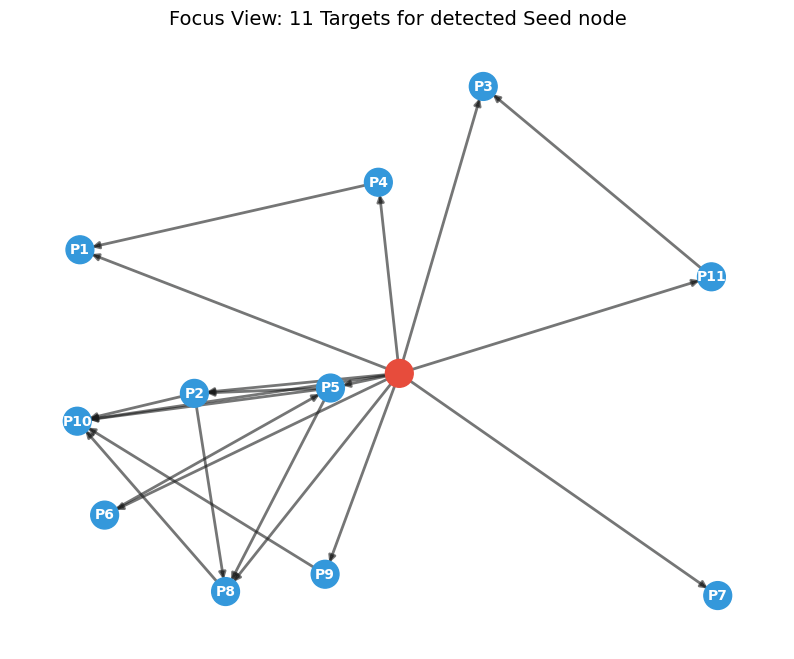

Verified: Found 11 connections for seed 10.1145/3543873.3587570


In [2]:
# 1. Load data
DIRECTORY = Path.cwd().parent / "csv"
nodes_df = pd.read_csv(DIRECTORY / 'knowledge_graph_nodes.csv')
edges_df = pd.read_csv(DIRECTORY / 'knowledge_graph_edges.csv')

# 2. Automatically find the Seed DOI from the nodes file
# This makes the code work for any file you upload
seed_nodes = nodes_df[nodes_df['Type'] == 'Seed']['NodeID'].tolist()

if not seed_nodes:
    print("No node with Type='Seed' found.")
else:
    # Focus on the first seed found
    dynamic_seed = seed_nodes[0]
    
    # 3. Build the Graph
    G = nx.from_pandas_edgelist(edges_df,
                                 source='Source',
                                   target='Target',
                                     create_using=nx.DiGraph())

    # 4. Identify the neighbors (targets) for the dynamic seed
    if dynamic_seed in G:
        neighbors = list(G.neighbors(dynamic_seed))
        nodes_to_show = [dynamic_seed] + neighbors
        H = G.subgraph(nodes_to_show)

        # 5. Calculate Layout with high repulsion (k) to avoid overlap
        # k=1.0 provides a very wide spread
        pos = nx.spring_layout(H, k=1.0, seed=42)

        # 6. Add Jitter to ensure 100% visibility of overlapping dots
        for node in pos:
            pos[node] = pos[node] + np.random.uniform(-0.04, 0.04, size=2)

        plt.figure(figsize=(10, 8))

        # 7. Draw the focused network
        nx.draw_networkx_edges(H, pos, width=2, edge_color="#1a1b1b", alpha=0.6)
        
        # Color: Seed is Red, others are Blue/Orange
        node_colors = ['#e74c3c' if n == dynamic_seed else '#3498db' for n in H.nodes()]
        nx.draw_networkx_nodes(H, pos, node_size=400, node_color=node_colors)

        # 8. Dynamic Labels: Show 'SEED' and references of seed paper as'P1, P2, P3...'
        label_map = {n: "SEED" if n == dynamic_seed else f"P{i}" 
                     for i, n in enumerate(neighbors, 1)}
        nx.draw_networkx_labels(H, pos, labels=label_map, font_size=10, font_color='white', font_weight='bold')

        plt.title(f"Focus View: {len(neighbors)} Targets for detected Seed node", fontsize=14)
        plt.axis('off')
        plt.show()
        
        print(f"Verified: Found {len(neighbors)} connections for seed {dynamic_seed}")
    else:
        print(f"Seed DOI {dynamic_seed} has no connections in the edges file.")

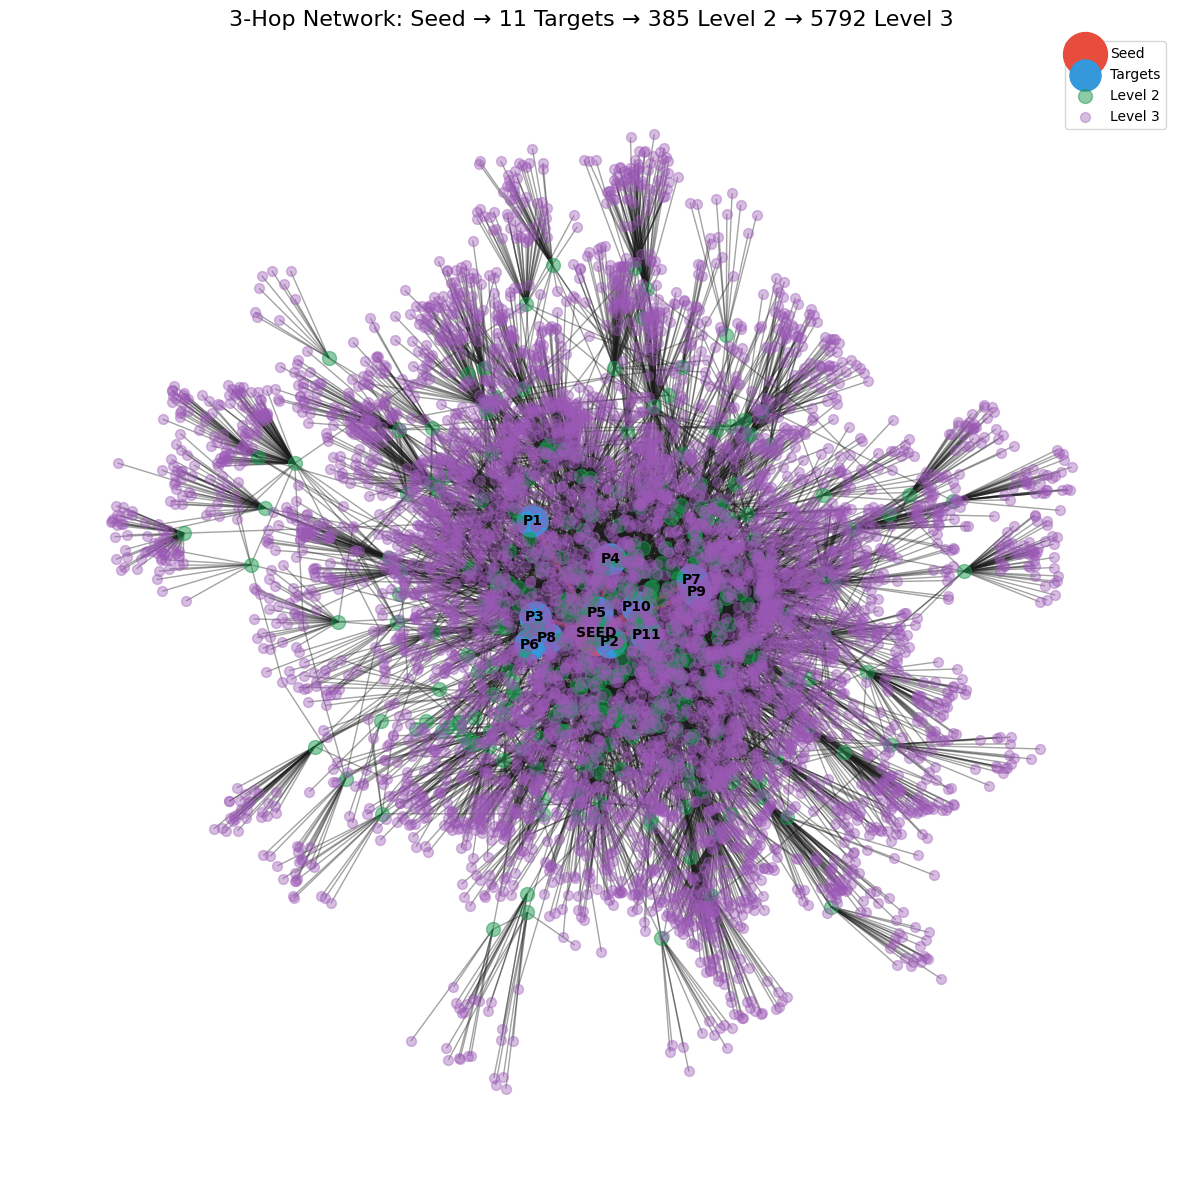

Count Check: Seed (1) + Targets (11) + Level 2 (385) + Level 3 (5792)


In [3]:
# 2. Build the Graph
G = nx.from_pandas_edgelist(edges_df,
                            source='Source',
                             target='Target',
                                create_using=nx.Graph())
node_attr = nodes_df.set_index('NodeID').to_dict('index')
nx.set_node_attributes(G, node_attr)

# 3. Detect Layers Dynamically
# Find the Seed automatically
seeds = [n for n, attr in G.nodes(data=True) if attr.get('Type') == 'Seed']
seed = seeds[0]

# Level 1: Neighbors of the Seed (The 10 Targets)
level1 = list(G.neighbors(seed))

# Level 2: Neighbors of the Targets (The References of Targets)
level2 = set()
for n in level1:
    for neighbor in G.neighbors(n):
        if neighbor != seed and neighbor not in level1:
            level2.add(neighbor)
level2 = list(level2)

# Level 3: Neighbors of Level 2 nodes
level3 = set()
for n in level2:
    for neighbor in G.neighbors(n):
        if neighbor != seed and neighbor not in level1 and neighbor not in level2:
            level3.add(neighbor)
level3 = list(level3)

# 4. Create the Shell Layout
# This forces nodes into circles: [Center, 2nd Ring, 3rd Ring, Outer Ring]
shells = [[seed], level1, level2, level3]
# pos = nx.shell_layout(G.subgraph([seed] + level1 + level2 + level3), shells)
pos = nx.spring_layout(G.subgraph([seed] + level1 + level2 + level3), pos=pos, k=0.5, seed=42)

# 5. Visualization
plt.figure(figsize=(15, 15))

# Draw everything
nx.draw_networkx_nodes(G, pos, nodelist=[seed], node_color='#e74c3c', node_size=1000, label='Seed')
nx.draw_networkx_nodes(G, pos, nodelist=level1, node_color='#3498db', node_size=500, label='Targets')
nx.draw_networkx_nodes(G, pos, nodelist=level2, node_color="#1b984f", node_size=100, alpha=0.5, label='Level 2')
nx.draw_networkx_nodes(G, pos, nodelist=level3, node_color="#9b59b6", node_size=50, alpha=0.4, label='Level 3')

# Draw connections
nx.draw_networkx_edges(G, pos, alpha=0.4, edge_color="#1b1b1b")
# Highlight Seed -> Target connections in Red
nx.draw_networkx_edges(G, pos, edgelist=[(seed, n) for n in level1], width=3, edge_color="#e74c3c", alpha=0.5)

# Label the 10 Targets as P1, P2... P10 so you can count them easily
labels = {n: f"P{i+1}" for i, n in enumerate(level1)}
labels[seed] = "SEED"
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')

plt.title(f"3-Hop Network: Seed → {len(level1)} Targets → {len(level2)} Level 2 → {len(level3)} Level 3", fontsize=16)
plt.axis('off')
plt.legend(loc='upper right', fontsize=10)
plt.show()

print(f"Count Check: Seed (1) + Targets ({len(level1)}) + Level 2 ({len(level2)}) + Level 3 ({len(level3)})")


Katz Centrality for Level 1 (Seed's Neighbors)

In [4]:
# Create a subgraph containing only seed and level 1 nodes
level1_nodes = [seed] + level1
G_level1_directed = nx.DiGraph()
edges_df_clean = edges_df.dropna(subset=["Source", "Target"])
for edge in edges_df_clean.itertuples(index=False):
    if edge.Source in level1_nodes and edge.Target in level1_nodes:
        G_level1_directed.add_edge(edge.Source, edge.Target)


alpha_level1 = 0.1  # Higher alpha since this is a smaller graph
katz_level1 = nx.katz_centrality_numpy(G_level1_directed, alpha=alpha_level1)

katz_level1_df = pd.DataFrame(katz_level1.items(), columns=["DOI", "Katz_Centrality_Level1"])
katz_level1_df = katz_level1_df.merge(
    nodes_df[['NodeID', 'PaperTitle', 'Abstract']], 
    left_on='DOI', 
    right_on='NodeID', 
    how='left'
).drop(columns=['NodeID'])


katz_level1_df = katz_level1_df.sort_values(by="Katz_Centrality_Level1", ascending=False).reset_index(drop=True)
print(f"Katz Centrality calculated for {len(level1_nodes)} nodes (1 seed + {len(level1)} level 1 papers)")
katz_level1_df.head(5)

Katz Centrality calculated for 12 nodes (1 seed + 11 level 1 papers)


,DOI,Katz_Centrality_Level1,PaperTitle,Abstract
0,10.1145/2623330.2623732,0.382127,DeepWalk: online learning of social representa...,"We present DeepWalk, a novel approach for lear..."
1,10.1016/j.knosys.2018.03.022,0.323316,"Graph Embedding Techniques, Applications, and ...",NaN
2,10.1109/TKDE.2018.2807452,0.293923,A Comprehensive Survey of Graph Embedding: Pro...,Graph is an important data representation whic...
3,10.18653/v1/D19-1371,0.291275,SciBERT: A Pretrained Language Model for Scien...,Obtaining large-scale annotated data for NLP t...
4,10.1609/AAAI.V34I04.5747,0.291275,Measuring and relieving the over-smoothing pro...,Graph Neural Networks (GNNs) have achieved pro...


<Figure size 800x500 with 0 Axes>

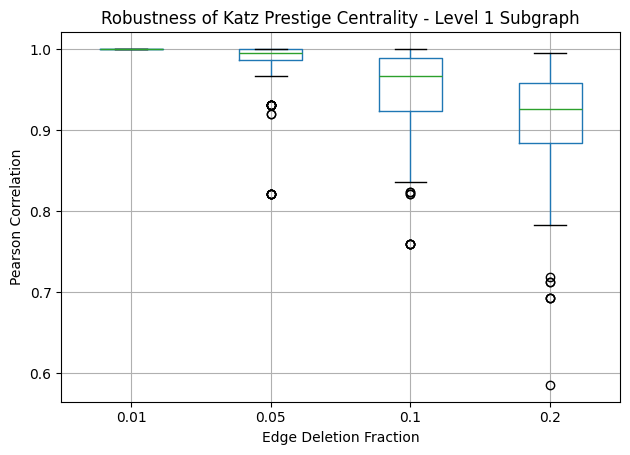

In [5]:
#Pearson Correlation in Katz Prestige
delete_fractions = [0.01, 0.05, 0.10, 0.20]
num_repeats = 100
katz_orig_rank = pd.Series(katz_level1).rank(method="min")

results = []
for frac in delete_fractions:
    for run in range(num_repeats):
        G_temp = G_level1_directed.copy()
        num_edges = int(frac * G_temp.number_of_edges())
        removed_edges = random.sample(list(G_temp.edges()), num_edges)
        G_temp.remove_edges_from(removed_edges)

        try:
            katz_temp = nx.katz_centrality_numpy(G_temp, alpha= alpha_level1)
            katz_temp_rank = pd.Series(katz_temp).reindex(katz_orig_rank.index).rank(method="min")
            corr, _ = pearsonr(katz_orig_rank, katz_temp_rank)
        except:
            corr = np.nan  

        results.append({
            "Fraction_Removed": frac,
            "Run": run,
            "Pearson_Correlation": corr
        })

results_df = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
results_df.boxplot(column="Pearson_Correlation", by="Fraction_Removed")
plt.title("Robustness of Katz Prestige Centrality - Level 1 Subgraph")
plt.suptitle("")
plt.xlabel("Edge Deletion Fraction")
plt.ylabel("Pearson Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()

Katz Centrality for Level 1 and Level 2 (Seed + Two Hops)

In [6]:
# Add level 2 nodes and edges
G_level2_directed = G_level1_directed.copy()
level2_nodes = level1_nodes + level2

for edge in edges_df_clean.itertuples(index=False):
    if edge.Source in level2_nodes and edge.Target in level2_nodes:
        if not G_level2_directed.has_edge(edge.Source, edge.Target):
            G_level2_directed.add_edge(edge.Source, edge.Target)

alpha_level2 = 0.05  # Adjusted alpha for medium-sized graph
katz_level2 = nx.katz_centrality_numpy(G_level2_directed,
                                               alpha=alpha_level2)

katz_level2_df = pd.DataFrame(katz_level2.items(),
                                      columns=["DOI", "Katz_Centrality_Level2"])
katz_level2_df = katz_level2_df.merge(
    nodes_df[['NodeID', 'PaperTitle', 'Abstract']], 
    left_on='DOI', 
    right_on='NodeID', 
    how='left'
).drop(columns=['NodeID'])

katz_level2_df = katz_level2_df.sort_values(
    by="Katz_Centrality_Level2", 
    ascending=False
    ).reset_index(drop=True)

print(f"Katz Centrality calculated for {len(level2_nodes)} nodes:")
katz_level2_df.head(10)

Katz Centrality calculated for 397 nodes:


,DOI,Katz_Centrality_Level2,PaperTitle,Abstract
0,10.1145/2623330.2623732,0.173090,DeepWalk: online learning of social representa...,"We present DeepWalk, a novel approach for lear..."
1,10.3115/v1/D14-1162,0.138517,GloVe: Global Vectors for Word Representation,Recent methods for learning vector space repre...
2,10.1145/2736277.2741093,0.129337,LINE: Large-scale Information Network Embedding,This paper studies the problem of embedding ve...
3,10.1162/neco.1997.9.8.1735,0.114758,Long Short-Term Memory,Learning to store information over extended ti...
4,10.1145/2939672.2939754,0.098210,node2vec: Scalable Feature Learning for Networks,Prediction tasks over nodes and edges in netwo...
5,10.1145/1390156.1390177,0.097981,A unified architecture for natural language pr...,NaN
6,10.1145/1557019.1557109,0.089635,Relational learning via latent social dimensions,NaN
7,10.1201/b17320-16,0.086602,Collective Classification in Network Data,NaN
8,10.1145/2806416.2806512,0.083766,GraRep: Learning Graph Representations with Gl...,NaN
9,10.17863/CAM.48429,0.079823,Graph Attention Networks,"We present graph attention networks (GATs), no..."


<Figure size 800x500 with 0 Axes>

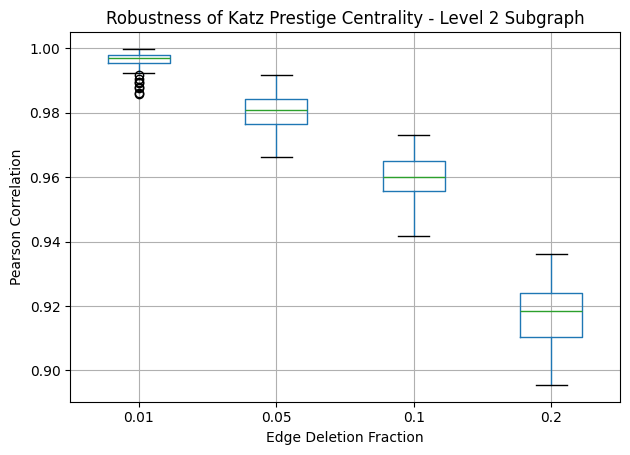

In [7]:
#Pearson Correlation in Katz Prestige - Level 2
delete_fractions = [0.01, 0.05, 0.10, 0.20]
num_repeats = 100
katz_orig_rank = pd.Series(katz_level2).rank(method="min")

results = []
for frac in delete_fractions:
    for run in range(num_repeats):
        G_temp = G_level2_directed.copy()
        num_edges = int(frac * G_temp.number_of_edges())
        removed_edges = random.sample(list(G_temp.edges()), num_edges)
        G_temp.remove_edges_from(removed_edges)

        try:
            katz_temp = nx.katz_centrality_numpy(G_temp, alpha= alpha_level2)
            katz_temp_rank = pd.Series(katz_temp).reindex(katz_orig_rank.index).rank(method="min")
            corr, _ = pearsonr(katz_orig_rank, katz_temp_rank)
        except:
            corr = np.nan  

        results.append({
            "Fraction_Removed": frac,
            "Run": run,
            "Pearson_Correlation": corr
        })

results_df = pd.DataFrame(results)
plt.figure(figsize=(8, 5))
results_df.boxplot(column="Pearson_Correlation", by="Fraction_Removed")
plt.title("Robustness of Katz Prestige Centrality - Level 2 Subgraph")
plt.suptitle("")
plt.xlabel("Edge Deletion Fraction")
plt.ylabel("Pearson Correlation")
plt.grid(True)
plt.tight_layout()
plt.show()

Katz Prestige (or Centrality) Calculation

In [8]:
# Katz Centrality Calculation
edges_df_cleaned = edges_df.dropna(subset=["Source", "Target"])

#Convert edge list to directed graph
G_original = nx.from_pandas_edgelist(edges_df_cleaned, 
                                     source='Source',
                                     target='Target',
                                     create_using=nx.DiGraph())

alpha = 0.005
katz_centrality = nx.katz_centrality_numpy(G_original, alpha=alpha)

katz_df = pd.DataFrame(katz_centrality.items(), columns=["DOI", "Katz_Prestige"])

katz_df = katz_df.dropna(subset=["DOI"])

katz_df = katz_df.merge(nodes_df[['NodeID', 'PaperTitle', 'Abstract']], left_on='DOI', right_on='NodeID', how='left')
katz_df = katz_df.drop(columns=['NodeID'])

katz_df = katz_df.sort_values(by="Katz_Prestige", ascending=False).reset_index(drop=True)

# katz_df.to_csv(DIRECTORY / 'katz_centrality_scores.csv', index=False)
katz_df.head(10)


,DOI,Katz_Prestige,PaperTitle,Abstract
0,10.1145/2623330.2623732,0.016049,DeepWalk: online learning of social representa...,"We present DeepWalk, a novel approach for lear..."
1,10.3115/v1/D14-1162,0.015204,GloVe: Global Vectors for Word Representation,Recent methods for learning vector space repre...
2,10.1145/2736277.2741093,0.014947,LINE: Large-scale Information Network Embedding,This paper studies the problem of embedding ve...
3,10.1162/neco.1997.9.8.1735,0.014503,Long Short-Term Memory,Learning to store information over extended ti...
4,10.1145/2939672.2939754,0.014285,node2vec: Scalable Feature Learning for Networks,Prediction tasks over nodes and edges in netwo...
5,10.1145/1390156.1390177,0.013875,A unified architecture for natural language pr...,NaN
6,10.17863/CAM.48429,0.013773,Graph Attention Networks,"We present graph attention networks (GATs), no..."
7,10.18653/v1/N18-1202,0.013772,Deep Contextualized Word Representations,We introduce a new type of deep contextualized...
8,10.1145/1557019.1557109,0.013736,Relational learning via latent social dimensions,NaN
9,10.1145/2806416.2806512,0.013725,GraRep: Learning Graph Representations with Gl...,NaN


Interpretation of Katz Centrality Across All Levels

Pearson correlation coefficient can be used to measure the linear relationship between Katz prestige scores. How katz prestige ranking change when a network slightly altered. It is revealing the robustness of the network.

<Figure size 800x500 with 0 Axes>

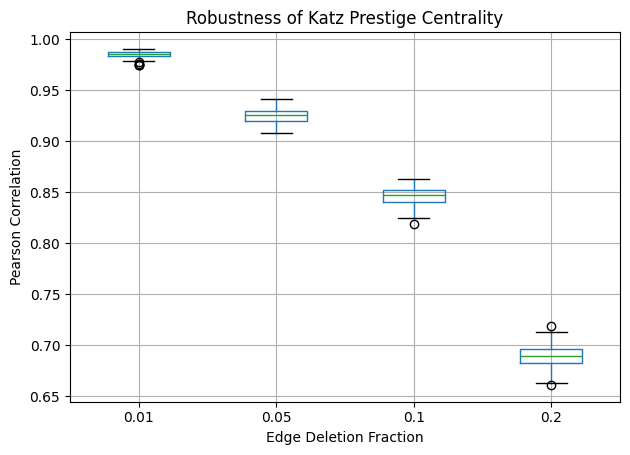

In [9]:
#Pearson Correlation in Katz Prestige
delete_fractions = [0.01, 0.05, 0.10, 0.20]
num_repeats = 100
# G_original = nx.from_pandas_edgelist(edges_df, source='Source', target='Target', create_using=nx.DiGraph())
katz_orig_rank = pd.Series(katz_centrality).rank(method="min")

results = []
for frac in delete_fractions:
    for run in range(num_repeats):
        G_temp = G_original.copy()
        num_edges = int(frac * G_temp.number_of_edges())
        removed_edges = random.sample(list(G_temp.edges()), num_edges)
        G_temp.remove_edges_from(removed_edges)

        try:
            katz_temp = nx.katz_centrality_numpy(G_temp, alpha=alpha)
            katz_temp_rank = pd.Series(katz_temp).reindex(katz_orig_rank.index).rank(method="min")
            corr, _ = pearsonr(katz_orig_rank, katz_temp_rank)
        except:
            corr = np.nan  

        results.append({
            "Fraction_Removed": frac,
            "Run": run,
            "Pearson_Correlation": corr
        })


results_df = pd.DataFrame(results)
results_df.head(15)


plt.figure(figsize=(8, 5))
results_df.boxplot(column="Pearson_Correlation", by="Fraction_Removed")
plt.title("Robustness of Katz Prestige Centrality")
plt.suptitle("")
plt.xlabel("Edge Deletion Fraction")
plt.ylabel("Pearson Correlation")
plt.grid(True)
plt.tight_layout()
# plt.savefig("katz_robustness_plot.png")
plt.show()

Eigenvector Centrality Measure

In [10]:
G_original = nx.from_pandas_edgelist(
    edges_df_cleaned,
    source="Source",
    target="Target",
    create_using=nx.DiGraph()
)


eigen_centrality = nx.eigenvector_centrality(G_original, max_iter=5000, tol=1e-06)


eigen_df = pd.DataFrame(eigen_centrality.items(), columns=["DOI", "Eigenvector_Centrality"])
eigen_df = eigen_df.dropna(subset=["DOI"])
eigen_df = eigen_df.merge(
    nodes_df[["NodeID", "PaperTitle", "Abstract"]],
    left_on="DOI",
    right_on="NodeID",
    how="left"
).drop(columns=["NodeID"])

eigen_df = eigen_df.sort_values(by="Eigenvector_Centrality", ascending=False).reset_index(drop=True)
eigen_df.head(10)

,DOI,Eigenvector_Centrality,PaperTitle,Abstract
0,10.1145/276304.276332,0.235528,Enhanced hypertext categorization using hyperl...,NaN
1,10.1145/956750.956830,0.218689,Learning relational probability trees,Classification trees are widely used in the ma...
2,10.21236/ADA452802,0.185334,A Simple Relational Classifier,NaN
3,10.1145/1014052.1014125,0.159214,Why collective inference improves relational c...,NaN
4,10.1198/016214502388618906,0.138457,Latent Space Approaches to Social Network Anal...,NaN
5,10.1145/1090193.1090201,0.137208,Leveraging relational autocorrelation with lat...,The presence of autocorrelation provides a str...
6,10.1145/1401890.1401925,0.134923,Using ghost edges for classification in sparse...,NaN
7,10.1198/016214501753208735,0.133193,Estimation and Prediction for Stochastic Block...,NaN
8,10.1109/TPAMI.1984.4767596,0.125778,"Stochastic Relaxation, Gibbs Distributions, an...",NaN
9,10.1146/annurev.soc.27.1.415,0.115045,Birds of a Feather: Homophily in Social Networks,Similarity breeds connection. This principle—t...


<Figure size 800x500 with 0 Axes>

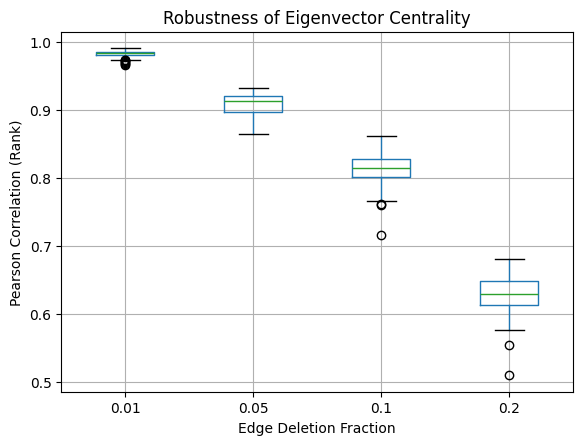

In [11]:
delete_fractions = [0.01, 0.05, 0.10, 0.20]
num_repeats = 100

MAX_ITER = 5000
TOL = 1e-6
RANDOM_SEED = 42 

rng = random.Random(RANDOM_SEED)

def eigenvector_centrality_safe(G_original, max_iter=5000, tol=1e-6, weight=None, fallback_scc=True):
    try:
        return nx.eigenvector_centrality(G_original, max_iter=max_iter, tol=tol, weight=weight)
    except nx.PowerIterationFailedConvergence:
        if not fallback_scc:
            raise
        sccs = list(nx.strongly_connected_components(G_original))
        if not sccs:
            return {}
        largest_scc = max(sccs, key=len)
        if len(largest_scc) < 3:
            return {}
        G_scc = G_original.subgraph(largest_scc).copy()
        return nx.eigenvector_centrality(G_scc, max_iter=max_iter, tol=tol, weight=weight)
    
eig_orig_rank = pd.Series(eigen_centrality).rank(method="min")
edges_list = list(G_original.edges())
m = len(edges_list)

results = []
for frac in delete_fractions:
    for run in range(num_repeats):
        G_temp = G_original.copy()
        num_edges_remove = int(frac * m)
        removed_edges = random.sample(list(G_temp.edges()), num_edges_remove)
        G_temp.remove_edges_from(removed_edges)

        try:
            eig_temp = eigenvector_centrality_safe(G_temp, max_iter=MAX_ITER, tol=TOL, weight=None, fallback_scc=True)
            eig_temp_rank = pd.Series(eig_temp).reindex(eig_orig_rank.index).rank(method="min")
            valid = eig_orig_rank.notna() & eig_temp_rank.notna()
            if valid.sum() >= 2:
                corr, _ = pearsonr(eig_orig_rank[valid], eig_temp_rank[valid])
            else:
                corr = np.nan

        except Exception:
            corr = np.nan

        results.append({
            "Fraction_Removed": frac,
            "Run": run,
            "Pearson_Correlation": corr,
            "Num_Edges_Removed": num_edges_remove
        })

results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 5))
results_df.boxplot(column="Pearson_Correlation", by="Fraction_Removed")
plt.title("Robustness of Eigenvector Centrality")
plt.suptitle("")
plt.xlabel("Edge Deletion Fraction")
plt.ylabel("Pearson Correlation (Rank)")
plt.grid(True)

Lovain Comunity Detection 

Modularity Score: 0.8060
Seed Paper '10.1145/3543873.3587570' is in Community: 0


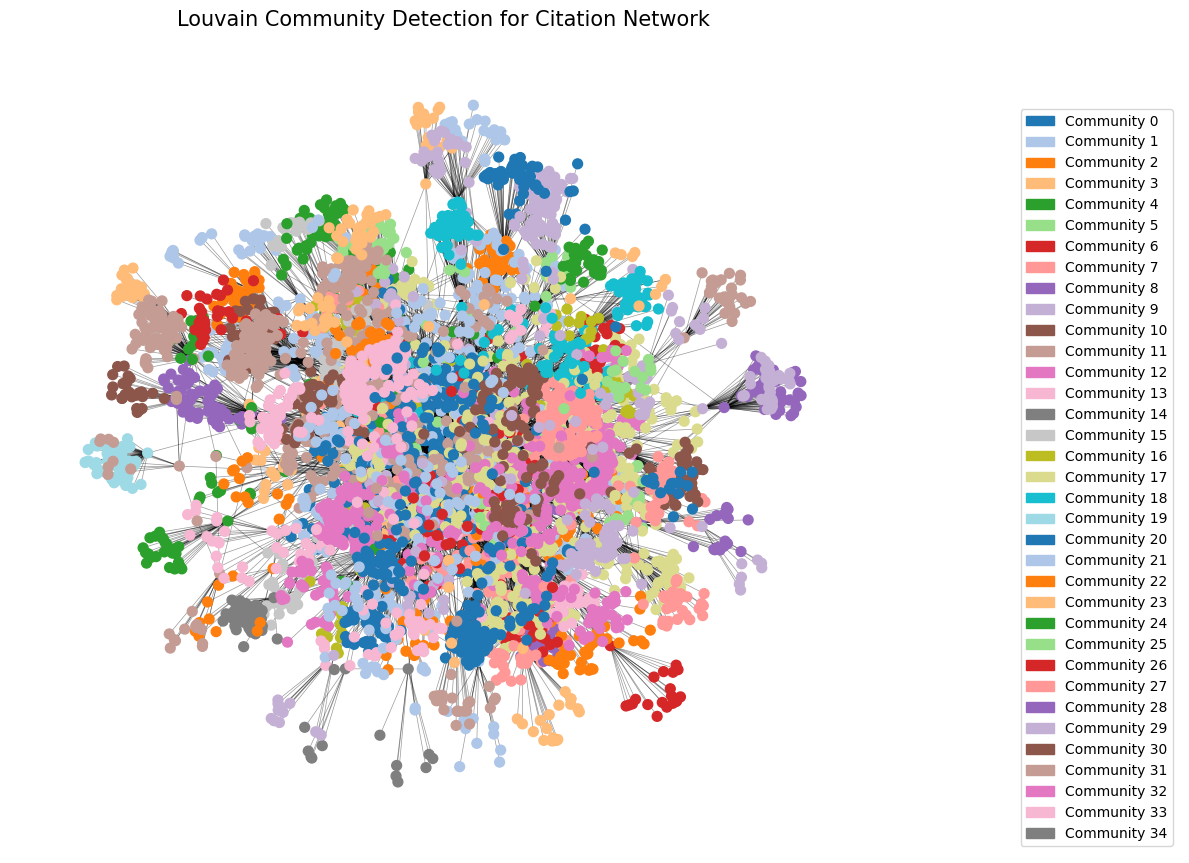

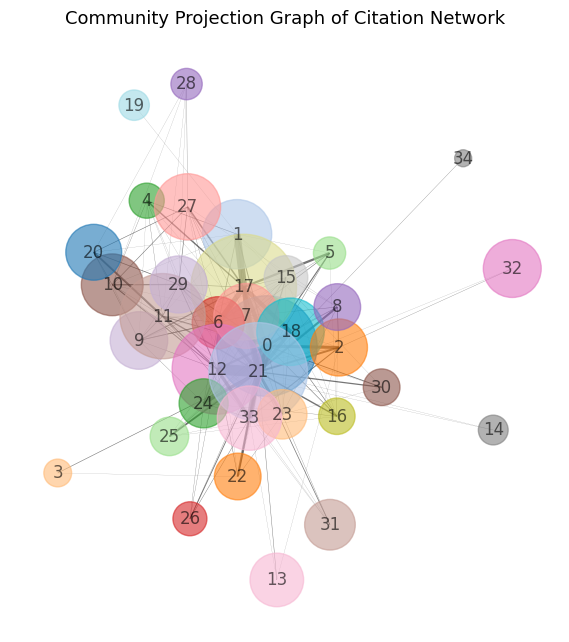

In [ ]:
seed_paper = "10.1145/3543873.3587570"
G = nx.from_pandas_edgelist(edges_df
                            , "Source", "Target", edge_attr=True, create_using=nx.Graph())

partition = community_louvain.best_partition(G, resolution=1.0)


modularity = community_louvain.modularity(partition, G)
print(f"Modularity Score: {modularity:.4f}")

core_comm = partition.get(seed_paper, "Not Found")
print(f"Seed Paper '{seed_paper}' is in Community: {core_comm}")

communities = defaultdict(list)
for node, cid in partition.items():
    communities[cid].append(node)

community_df = pd.DataFrame([(cid, paper) for cid, papers in communities.items() for paper in papers],
                            columns=["Community", "DOI"])

# Merge with nodes_df to get PaperTitle
community_df = community_df.merge(nodes_df[['NodeID', 'PaperTitle', 'Abstract']], left_on='DOI', right_on='NodeID', how='left')
community_df = community_df.drop(columns=['NodeID'])

# Create macro_groups with PaperTitle
community_groups_detailed = community_df.groupby("Community").apply(
    lambda x: x[['DOI', 'PaperTitle', 'Abstract']].to_dict('records')
).to_dict()

community_groups_df = pd.DataFrame([
    {
        "Community": m,
        "DOIs": "; ".join(str(paper['DOI']) for paper in papers if pd.notna(paper['DOI'])),
        "PaperTitles": "; ".join(str(paper['PaperTitle']) for paper in papers if pd.notna(paper.get('PaperTitle'))),
        "Abstracts": "; ".join(str(paper['Abstract']) for paper in papers if pd.notna(paper.get('Abstract')))
    }
    for m, papers in community_groups_detailed.items()
])

# Community ids and dois save to CSV
community_df.to_csv(DIRECTORY /"community_ids_with_dois.csv", index=False)
community_groups_df.to_csv(DIRECTORY /"community_groups_detailed.csv", index=False)

# === Plot: Full Network by Community ===
pos = nx.spring_layout(G,  center=(0, 0), seed=21)
base_cmap = plt.get_cmap("tab20")
colors = lambda i: base_cmap(i % base_cmap.N)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 9), gridspec_kw={'width_ratios': [3, 1]})
pos = nx.spring_layout(G, seed=42)
node_colors =  [colors(partition[node]) for node in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50, ax=ax1)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.4, ax=ax1)
ax1.set_title("Louvain Community Detection for Citation Network", fontsize=15)
ax1.axis("off")
ax2.axis("off")
patches = [mpatches.Patch(color=colors(i), label=f"Community {i}") for i in sorted(communities.keys())]
ax2.legend(handles=patches, loc='lower right', fontsize=10, frameon=True)
plt.tight_layout()
plt.show()

# Community Projection Graph 
G_proj = nx.Graph()
for cid, nodes in communities.items():
    G_proj.add_node(cid, size=len(nodes))

for u, v, data in G.edges(data=True):
    cu = partition[u]
    cv = partition[v]
    if cu != cv:
        if G_proj.has_edge(cu, cv):
            G_proj[cu][cv]['weight'] += 1
        else:
            G_proj.add_edge(cu, cv, weight=1)


plt.figure(figsize=(5.5, 6))
proj_pos = nx.spring_layout(G_proj, seed=42, k=1.5)
proj_colors = [colors(n) for n in G_proj.nodes()]
proj_sizes = [G_proj.nodes[n]['size'] * 10 for n in G_proj.nodes()]
edge_widths = [G_proj[u][v]['weight'] / 10 for u, v in G_proj.edges()]
nx.draw(G_proj, proj_pos, with_labels=True, node_color=proj_colors,
        node_size=proj_sizes, width=edge_widths, edge_color='#1b1b1b', alpha=0.6)
plt.title("Community Projection Graph of Citation Network", fontsize=13)
# plt.savefig("community_projection_graph.png", dpi=300, bbox_inches='tight')
plt.show()


Agglomerative Clustering

In [13]:
community_df = pd.read_csv(DIRECTORY /"community_ids_with_dois.csv")
G = nx.from_pandas_edgelist(edges_df, "Source", "Target")
seed_paper = "10.1145/3543873.3587570"
partition = {row["DOI"]: row["Community"] for _, row in community_df.iterrows()}
# modularity = community_louvain.modularity(partition, G)

community_nodes = {}
for _, row in community_df.iterrows():
    community_nodes.setdefault(row["Community"], set()).add(row["DOI"])

G_project = nx.Graph()
for c1, nodes1 in community_nodes.items():
    for c2, nodes2 in community_nodes.items():
        if c1 < c2 and any(G.has_edge(n1, n2) for n1 in nodes1 for n2 in nodes2):
            G_project.add_edge(c1, c2)

adjacency_matrix = nx.to_numpy_array(G_project, nodelist=sorted(G_project.nodes()))
distance_matrix = 1 - adjacency_matrix
np.fill_diagonal(distance_matrix, 0)
community_ids = sorted(G_project.nodes())

threshold_candidates = np.linspace(0.2, 0.9, 15)
best_threshold = None
best_score = -1

for threshold in threshold_candidates:
    model = AgglomerativeClustering(metric="precomputed", linkage="average",distance_threshold=threshold,n_clusters=None)
    labels = model.fit_predict(distance_matrix)
    if len(set(labels)) < 2 or len(set(labels)) >= len(labels):
        continue
    score = silhouette_score(distance_matrix, labels, metric="precomputed")
    if score > best_score:
        best_score = score
        best_threshold = threshold
     
print(f"Optimal distance threshold: {best_threshold:.3f}")
print(f"Best silhouette score: {best_score:.4f}")

clustering = AgglomerativeClustering(
    metric='precomputed',
    linkage='average',
    distance_threshold=best_threshold, 
    n_clusters=None
)

macro_labels = clustering.fit_predict(distance_matrix)
map_macro_community = {comm: macro for comm, macro in zip(community_ids, macro_labels)}
community_df["Macro_Community"] = community_df["Community"].map(map_macro_community)

seed_paper_macro_comm = community_df.loc[community_df["DOI"] == seed_paper, "Macro_Community"].values
if len(seed_paper_macro_comm) > 0:
    print(f"Seed paper '{seed_paper}' is in Macro Community: {seed_paper_macro_comm[0]}")
else:
    print(f"Seed paper '{seed_paper}' not found in the dataset.")

# Merge with nodes_df to get PaperTitle if not already present
if 'PaperTitle' not in community_df.columns:
    community_df = community_df.merge(nodes_df[['NodeID', 'PaperTitle', 'Abstract']], left_on='DOI', right_on='NodeID', how='left')
    community_df = community_df.drop(columns=['NodeID'])

community_df.to_csv(DIRECTORY /"macro_communities.csv", index=False)

# Create macro_groups with PaperTitle
macro_groups_detailed = community_df.groupby("Macro_Community").apply(
    lambda x: x[['DOI', 'PaperTitle', 'Abstract']].to_dict('records')
).to_dict()

macro_groups_df = pd.DataFrame([
    {
        "Macro_Community": m,
        "DOIs": "; ".join(str(paper['DOI']) for paper in papers if pd.notna(paper['DOI'])),
        "PaperTitles": "; ".join(str(paper['PaperTitle']) for paper in papers if pd.notna(paper.get('PaperTitle'))),
        "Abstracts": "; ".join(str(paper['Abstract']) for paper in papers if pd.notna(paper.get('Abstract')))
    }
    for m, papers in macro_groups_detailed.items()
])
macro_groups_df.to_csv(DIRECTORY /"macro_community_groups.csv", index=False)


Optimal distance threshold: 0.200
Best silhouette score: 0.4571
Seed paper '10.1145/3543873.3587570' is in Macro Community: 14


C:\Users\thenu\AppData\Local\Temp\ipykernel_12852\859254222.py:64: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  macro_groups_detailed = community_df.groupby("Macro_Community").apply(


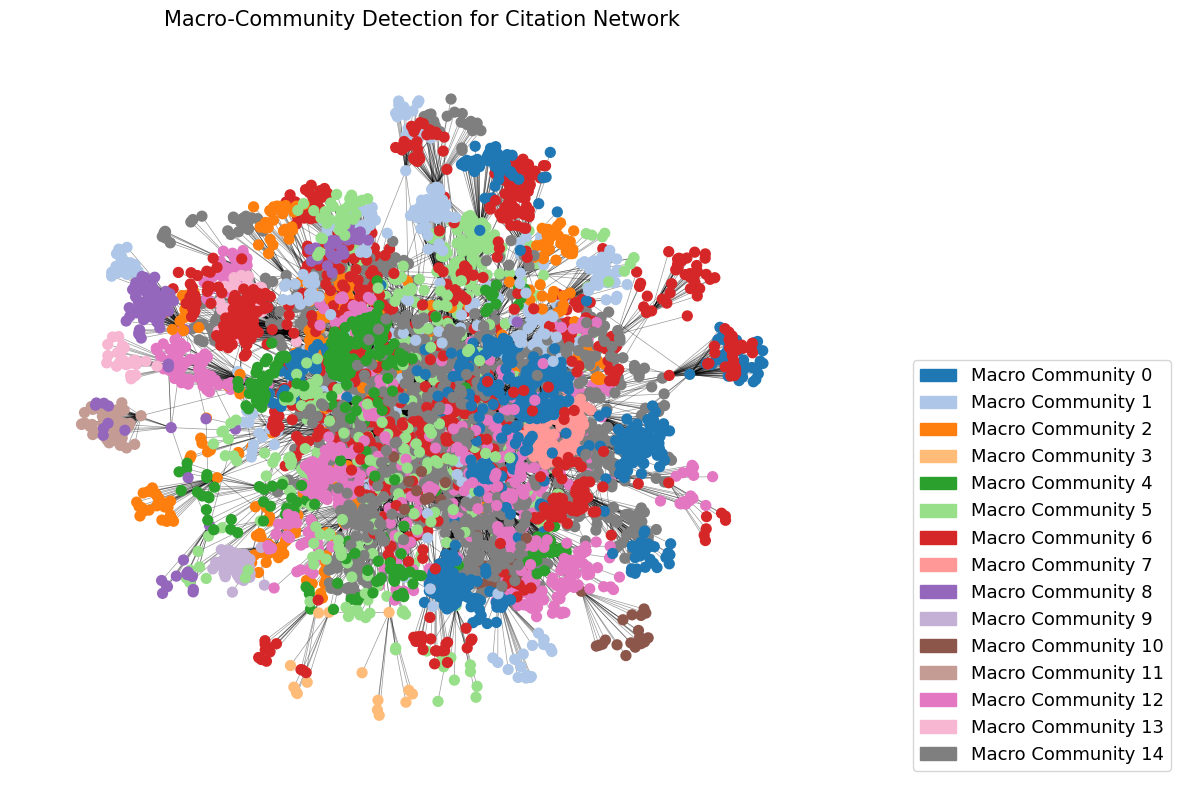

In [14]:
# === Color Mapping =====
macro_ids = sorted(set(macro_labels))
cmap = cm.tab20
macro_color_dict = {m: cmap(i % 20) for i, m in enumerate(macro_ids)}
act_macro_map = dict(zip(community_df["DOI"], community_df["Macro_Community"]))

# === Plot: Full Network by Macro-Community ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [3, 1]})
pos = nx.spring_layout(G, seed=42)
node_colors = [macro_color_dict.get(act_macro_map.get(n, -1), "#1b1b1b") for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=50, ax=ax1)
nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.4, ax=ax1)
ax1.set_title("Macro-Community Detection for Citation Network", fontsize=15)
ax1.axis("off")
ax2.axis("off")
patches = [mpatches.Patch(color=macro_color_dict[i], label=f"Macro Community {i}") for i in macro_ids]
ax2.legend(handles=patches, loc='lower right', fontsize=13, frameon=True)
plt.tight_layout()
plt.show()


C:\Users\thenu\AppData\Local\Temp\ipykernel_12852\599123932.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


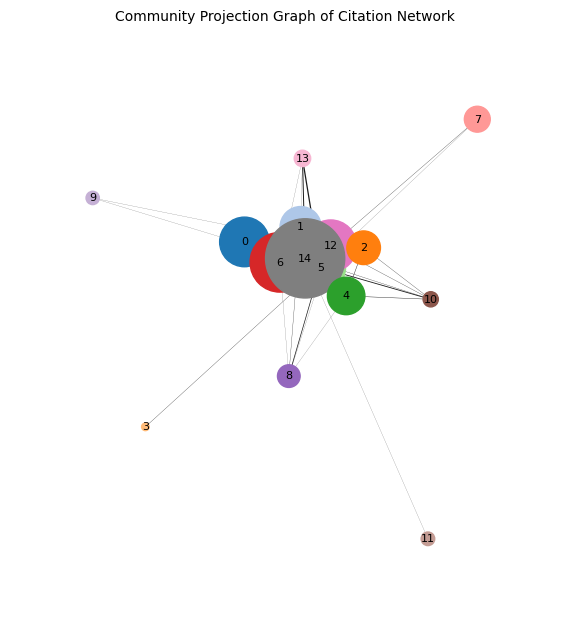

In [ ]:
macro_nodes = community_df.groupby("Macro_Community")["DOI"].apply(set).to_dict()
G_proj_macro = nx.Graph()

for i, mi in enumerate(macro_ids):
    for mj in macro_ids[i + 1:]:
        edge_count = sum(
            1 for a1 in macro_nodes[mi]
              for a2 in macro_nodes[mj]
              if G.has_edge(a1, a2)
        )
        if edge_count > 0:
            G_proj_macro.add_edge(mi, mj, weight=edge_count)



macro_sizes = [len(macro_nodes[m]) * 2 for m in G_proj_macro.nodes()]
macro_colors = [macro_color_dict[m] for m in G_proj_macro.nodes()]
edge_widths = [G_proj_macro[u][v]['weight'] /10 for u, v in G_proj_macro.edges()]

plt.figure(figsize=(5.5, 6))
pos = nx.spring_layout(G_proj_macro, seed=42, scale=5, k=1.2)

nx.draw(
    G_proj_macro,
    pos,
    with_labels=True,
    node_size=macro_sizes,
    node_color=macro_colors,
    width=edge_widths,
    edge_color="#1b1b1b",
    font_size=8
)

plt.title("Community Projection Graph of Citation Network", fontsize=10)
plt.axis("off")
plt.margins(0.15)
plt.tight_layout()
plt.show()